<a href="https://colab.research.google.com/github/iesataulfoargentasor/sbd_2026_2027_new/blob/main/notebooks/matematica_discreta_bigdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Matemática Discreta aplicada a Big Data — Cuaderno de prácticas (Google Colab)

Este cuaderno contiene **ejemplos sencillos en Python** para cada concepto clave: conjuntos, relaciones, funciones, lógica, grafos, combinatoria, teoría de grupos (visión aplicada) y estructuras de datos (vectores, matrices, tablas, árboles).

> Ejecuta cada celda y lee los comentarios. Todos los ejemplos están pensados para ser cortos, claros y fáciles de relacionar con **casos de Big Data**.

**Cómo está organizado cada bloque:** primero una celda de texto con el *contexto* (la historia de negocio que hay detrás), después la celda de código comentada paso a paso, y al final un **resumen en tabla** con la idea clave.

**Los protagonistas:** a lo largo de todo el cuaderno seguimos a un mismo grupo de personas (Ana, Juan, Marta, Sofía, y más adelante Luis y Pedro) para que cada concepto nuevo se apoye en el anterior.


## 1) Conjuntos — operaciones básicas y ejemplo de negocio

**Idea:** combinar datasets y buscar elementos comunes/únicos.


# 🏪 El contexto: una tienda con dos productos

Antes de ejecutar el código, entendamos **qué estamos representando**.

Imagina una tienda que vende **dos productos: el producto X y el producto Y**. Al final del mes revisamos los tickets de compra y apuntamos dos listas de nombres:

*   **Lista A** → quién compró el producto X: `Ana, Juan, Marta, Sofía`
*   **Lista B** → quién compró el producto Y: `Juan, Luis, Sofía, Pedro`

Fíjate en un detalle importante: **Juan y Sofía aparecen en las dos listas**, porque compraron los dos productos. Ese "solapamiento" es justo lo que hace interesantes las operaciones que vamos a hacer.

En Python, cada lista la guardamos como un **conjunto** (`set`): una bolsa de elementos **sin orden y sin duplicados**. Si Juan compró X tres veces, su nombre aparece una sola vez, como en una lista de asistencia.

```
A = {"Ana", "Juan", "Marta", "Sofía"}  
B = {"Juan", "Luis", "Sofía", "Pedro"}
```

Cada operación de la celda siguiente es, en el fondo, **una pregunta de negocio** que le hacemos a esas dos listas.

---

## 1️⃣ Unión — `A | B` → *«¿Quién ha comprado ALGO?»*

Juntamos las dos listas en una sola, **quitando los repetidos**:

> **Ana, Juan, Marta, Sofía, Luis, Pedro** — 6 personas

Juan y Sofía estaban en las dos listas, pero cuentan **una sola vez**.

**Para qué sirve:** es la *audiencia total* de la tienda. Si quieres enviar un mensaje a todos tus clientes sin repetir a nadie, o calcular "¿cuántos clientes únicos tengo?", usas la unión.

---

## 2️⃣ Intersección — `A & B` → *«¿Quién compró los DOS productos?»*

Buscamos los nombres que aparecen **en las dos listas a la vez**:

> **Juan, Sofía** — 2 personas

**Para qué sirve:** son tus **clientes más completos**: compran de todo. Si sacas un producto nuevo, estas personas son las primeras a las que se lo cuentas. En marketing se les llama clientes *cruzados* y son la diana del *cross-selling* (venta cruzada: venderle a quien ya compró X el producto Y).

---

## 3️⃣ Diferencia — `A - B` → *«¿Quién compró X pero le FALTA Y?»*

Empezamos con la lista A (los del producto X) y **tachamos los nombres que también están en B** (los que ya compraron Y):

> Ana ✓ · Juan ✗ (también compró Y) · Marta ✓ · Sofía ✗ (también compró Y)
>
> **Queda: Ana, Marta** — 2 personas

**Para qué sirve:** es la lista perfecta para una **oferta dirigida**. ¿Quieres vender más unidades del producto Y? Se lo ofertas exactamente a estas personas: ya confían en ti (compraron X) pero todavía no tienen Y. Es la lógica *"aún no lo tienes → te lo ofrezco"*.

---

## 4️⃣ Diferencia simétrica — `A ^ B` → *«¿Quién compró SOLO UNO de los dos?»*

Como la diferencia, pero **mirando en las dos direcciones a la vez**:

*   de la lista A, los que **no** están en B → `Ana, Marta`
*   de la lista B, los que **no** están en A → `Luis, Pedro`

> **Ana, Marta, Luis, Pedro** — 4 personas

Dicho al revés: son *todos menos los compradores dobles* (Juan y Sofía quedan fuera).

**Para qué sirve:** detecta a los clientes **"de un solo producto"**: solo compran X o solo compran Y, nunca cruzan. Cada uno es un cliente al que todavía puedes convencer de comprar el otro producto.

---

## 5️⃣ Producto cartesiano — `product(A, productos)` → *«¿Qué parejas puedo formar?»*

Esta operación es distinta: no cruza las dos listas de clientes entre sí, sino que **cruza los clientes con los productos** (`X` e `Y`):

|           | producto X | producto Y |
| --------- | ---------- | ---------- |
| **Ana**   | (Ana, X)   | (Ana, Y)   |
| **Juan**  | (Juan, X)  | (Juan, Y)  |
| **Marta** | (Marta, X) | (Marta, Y) |
| **Sofía** | (Sofía, X) | (Sofía, Y) |

Son **todas las parejas posibles**: 4 clientes × 2 productos = **8 combinaciones**.

**Para qué sirve:** genera el **mapa completo de lo que podría pasar**, exista o no en los datos. Piensa en Netflix: usuarios y películas. El cartesiano crea todas las combinaciones "usuario-película" posibles; al compararlas con lo que cada usuario ya vio, las casillas vacías son las recomendaciones. Aquí igual: la pareja `(Ana, Y)` significa *"Ana todavía no compró Y → oportunidad"*.

---

## 🎯 Resumen

| Pregunta de negocio         | Operación            | Operador        | Resultado               |
| --------------------------- | -------------------- | --------------- | ----------------------- |
| ¿Quién compró algo?         | Unión                | `A \| B`        | 6 clientes              |
| ¿Quién compró ambos?        | Intersección         | `A & B`         | Juan, Sofía             |
| ¿A quién le falta Y?        | Diferencia           | `A - B`         | Ana, Marta              |
| ¿Quién solo compra uno?     | Diferencia simétrica | `A ^ B`         | Ana, Marta, Luis, Pedro |
| ¿Qué combinaciones existen? | Producto cartesiano  | `product(A, P)` | 8 parejas               |

> 💡 **La idea clave:** las tres primeras te dicen *quién es cada cliente* (total, fiel, con hueco), y el producto cartesiano te da el *mapa completo de lo posible*. Por eso estas operaciones están detrás del análisis de clientes, las recomendaciones y los JOIN de SQL.


In [1]:
# Conjuntos de clientes que compraron distintos productos
A = {"Ana", "Juan", "Marta", "Sofía"}
B = {"Juan", "Luis", "Sofía", "Pedro"}

print("A =", A)
print("B =", B)

# Operaciones
union = A | B                 # A ∪ B
interseccion = A & B          # A ∩ B
diferencia = A - B            # A − B
diferencia_simetrica = A ^ B  # (A - B) ∪ (B - A)

from itertools import product
# Producto cartesiano: (cliente, producto)
productos = {"X", "Y"}
cartesiano = list(product(A, productos))

print("\nUnión (A ∪ B):", union)
print("Intersección (A ∩ B):", interseccion)
print("Diferencia (A − B):", diferencia)
print("Diferencia simétrica:", diferencia_simetrica)
print("\nProducto cartesiano (primeros 6):", cartesiano[:6])


A = {'Marta', 'Ana', 'Juan', 'Sofía'}
B = {'Luis', 'Juan', 'Pedro', 'Sofía'}

Unión (A ∪ B): {'Juan', 'Luis', 'Sofía', 'Ana', 'Pedro', 'Marta'}
Intersección (A ∩ B): {'Juan', 'Sofía'}
Diferencia (A − B): {'Marta', 'Ana'}
Diferencia simétrica: {'Luis', 'Ana', 'Pedro', 'Marta'}

Producto cartesiano (primeros 6): [('Marta', 'X'), ('Marta', 'Y'), ('Ana', 'X'), ('Ana', 'Y'), ('Juan', 'X'), ('Juan', 'Y')]


## 2) Relaciones — modelar conexiones entre elementos

**Idea:** representar relaciones (por ejemplo, amistad) como conjunto de pares ordenados. También analizamos propiedades simples (simetría y reflexividad).


# 👥 El contexto: una mini red social

Este código estudia **quién es amigo de quién** dentro de un grupo de cuatro personas. Pero antes de ejecutarlo, entendamos la idea.

Tenemos un grupo de personas:

```
Personas = {"Ana", "Juan", "Marta", "Sofía"}
```

Y una lista de amistades. Lo importante es **cómo se representan**: como **pares ordenados** dentro de un conjunto:

```
es_amigo = {("Ana", "Juan"), ("Juan", "Ana"), ("Ana", "Sofía"), ("Marta", "Ana")}
```

## 📌 Qué es un "par ordenado"

Cada tupla `(a, b)` se lee de izquierda a derecha y significa: **`a` considera amiga a `b`**.

*   `("Ana", "Juan")` → Ana considera amigo a Juan
*   `("Juan", "Ana")` → Juan considera amiga a Ana

La palabra clave es **ordenado**: `("Ana", "Juan")` y `("Juan", "Ana")` son **pares distintos**. En la vida real la amistad no siempre es mutua (piensa en *seguir a alguien* en Twitter o Instagram: tú le sigues, pero esa persona no tiene por qué seguirte). Por eso una relación puede ser **no simétrica**: Ana puede considerar amiga a Sofía aunque Sofía no la considere a ella.

Con este dibujo mental — *flechas que salen de cada persona hacia sus amigos* — todo lo que hace el código es preguntar cosas sobre esas flechas.

---

## 1️⃣ ¿Es reflexiva? — *«¿Cada persona se considera amiga de sí misma?»*

Una relación es **reflexiva** si **todo elemento está relacionado consigo mismo**: para cada persona `x`, el par `(x, x)` debe estar en la relación.

Para nuestro grupo harían falta estos pares:

> (Ana, Ana) · (Juan, Juan) · (Marta, Marta) · (Sofía, Sofía)

Si abres `es_amigo` y buscas… **ninguno está**. Luego la relación **no es reflexiva**.

```
def es_reflexiva(rel, conjunto):  
    return all((x, x) in rel for x in conjunto)
```

**Cómo lo lee Python:** `all(...)` devuelve `True` solo si **todas** las comprobaciones son `True`. La expresión `(x, x) in rel for x in conjunto` es un **generador**: recorre cada persona *una a una, sin crear una lista intermedia*, y comprueba si su par consigo misma existe. Con que **falte una sola**, `all` devuelve `False`.

**Para qué sirve:** piensa en la relación *"es igual a"* (=) o *"vive en la misma ciudad que"*. Esas sí son reflexivas (tú vives en tu misma ciudad…). En cambio, *"es madre de"* o nuestra amistad dirigida no lo son. Clasificar relaciones así es la base para trabajar con ellas.

---

## 2️⃣ ¿Es simétrica? — *«Cuando alguien considera amigo a otro, ¿el otro le devuelve la amistad?»*

Una relación es **simétrica** si **todas las flechas van en los dos sentidos**: para cada par `(a, b)` que existe, también debe existir `(b, a)`.

Comprobémoslo flecha por flecha sobre `es_amigo`:

| Par que existe | ¿Existe el inverso? |        |
| -------------- | ------------------- | ------ |
| (Ana, Juan)    | (Juan, Ana) ✓       | Sí     |
| (Juan, Ana)    | (Ana, Juan) ✓       | Sí     |
| (Ana, Sofía)   | (Sofía, Ana) ✗      | **No** |
| (Marta, Ana)   | (Ana, Marta) ✗      | **No** |

Con que **una sola** flecha no tenga su inversa, la respuesta ya es `False`: **la relación no es simétrica**. Ana quiere a Sofía, pero Sofía no le corresponde.

```
def es_simetrica(rel):  
    return all((b, a) in rel for (a, b) in rel)
```

**Cómo lo lee Python:** recorre cada par `(a, b)` de la relación y comprueba si está su inverso `(b, a)`. Otra vez `all(...)`: todas deben cumplirse.

**Para qué sirve:** distingue entre redes de amistad **mutua** (los amigos de Facebook: si eres mi amigo, yo soy tu amigo → relación simétrica) y redes de **seguimiento** (Twitter/Instagram: puedes seguir a quien no te sigue → no simétrica). También aparecen en bases de datos y grafos: "es colega de", "enlaza a"…

---

## 3️⃣ La lista de adyacencia — *«¿Cómo guarda esto una red social de verdad?»*

Hasta ahora la relación es una bolsa de pares sueltos. Pero si quieres responder rápido a *"¿quiénes son los amigos de Ana?"* tendrías que revolver toda la bolsa.

La solución: reorganizar la información **por persona**, en un diccionario donde cada clave es una persona y su valor es **el conjunto de sus amigos**:

```
adyacencia = {p: set() for p in Personas}   # una entrada (vacía) por persona  
for a, b in es_amigo:  
    adyacencia[a].add(b)                    # b entra en la lista de amigos de a
```

**Paso a paso:**

1.  Se crea el diccionario con una entrada vacía por persona: `{"Ana": set(), "Juan": set(), "Marta": set(), "Sofía": set()}`
2.  Se recorre cada par `(a, b)` y se añade `b` a los amigos de `a`:
    *   `(Ana, Juan)` → Juan entra en los amigos de Ana
    *   `(Juan, Ana)` → Ana entra en los amigos de Juan
    *   `(Ana, Sofía)` → Sofía entra en los amigos de Ana
    *   `(Marta, Ana)` → Ana entra en los amigos de Marta

Y queda así (es la **lista de adyacencia** de esta red de amistades; en la sección de grafos la volveremos a encontrar como la forma estándar de almacenar una red):

| Persona   | Sus amigos (según la relación) |
| --------- | ------------------------------ |
| **Ana**   | Juan, Sofía                    |
| **Juan**  | Ana                            |
| **Marta** | Ana                            |
| **Sofía** | *nadie*                        |

Fíjate en **Sofía**: aparece como amiga de Ana (tiene una flecha *entrante*), pero ella no considera amiga a nadie (su lista está vacía). Esa asimetría que detectamos antes se ve aquí de un vistazo.

**Para qué sirve:** así es como almacenan las redes los sistemas reales: redes sociales, mapas de carreteras (ciudades → ciudades conectadas), navegadores. Con esta estructura, consultar los amigos de una persona es **inmediato** (sin buscar en toda la lista de pares), y es el punto de partida para algoritmos clásicos: sugerir amigos, calcular grados de separación, recomendar a quién seguir…

---

## 🎯 Resumen

| Bloque del código   | Pregunta que responde                             | Resultado con nuestros datos                     |
| ------------------- | ------------------------------------------------- | ------------------------------------------------ |
| `es_reflexiva(...)` | ¿Todos se consideran amigo de sí mismos?          | `False` (ningún par (x, x) existe)               |
| `es_simetrica(...)` | ¿Todas las amistades son mutuas?                  | `False` (Ana→Sofía y Marta→Ana no tienen vuelta) |
| `adyacencia`        | ¿Quién es amigo de quién, organizado por persona? | Diccionario listo para consultar al instante     |

> 💡 **La idea clave:** un conjunto de pares ordenados es la forma *matemática* de expresar una relación (aquí, la amistad); las propiedades (reflexiva, simétrica…) son *preguntas de negocio* sobre esa relación; y la lista de adyacencia es su forma *práctica* de almacenarla para consultarla rápido. Mismo dato, tres vistas: matemática → pregunta → estructura de datos.


In [2]:
# Aquí defines un conjunto (set) de personas.
# Los conjuntos en Python no tienen orden y no permiten duplicados.
Personas = {"Ana", "Juan", "Marta", "Sofía"}
# Relación "es_amigo" representada como pares (a,b)
# Aquí defines otro conjunto, pero esta vez de pares ordenados (tuplas).
# Cada tupla (a, b) significa que a es amigo de b.
#
# Por ejemplo:
# * ("Ana", "Juan") significa Ana es amiga de Juan.
# * ("Juan", "Ana") significa Juan es amigo de Ana
#
# Observa que una relación puede ser no simétrica (por ejemplo, Ana puede ser
# amiga de Sofía, pero no necesariamente al revés).

es_amigo = {("Ana", "Juan"), ("Juan", "Ana"), ("Ana", "Sofía"), ("Marta", "Ana")}

print("Relación es_amigo =", es_amigo)

# Comprobar propiedades sencillas
def es_reflexiva(rel, conjunto):
    return all((x, x) in rel for x in conjunto)

def es_simetrica(rel):
    return all((b, a) in rel for (a, b) in rel)

print("¿Reflexiva?", es_reflexiva(es_amigo, Personas))
print("¿Simétrica?", es_simetrica(es_amigo))

# Construir lista de adyacencia (quién es amigo de quién)
# Se crea un diccionario con una clave por cada persona, y como valor un conjunto vacío.
# Inicialmente: {"Ana": set(), "Juan": set(), "Marta": set(), "Sofía": set()}
adyacencia = {p: set() for p in Personas}

# Recorre cada par (a, b) de la relación y agrega b a los amigos de a.
# Por ejemplo: (Ana, Juan) → agrega "Juan" a los amigos de Ana.
for a, b in es_amigo:
    adyacencia[a].add(b)

# Imprime cada persona (k) y sus amigos (v), ordenados alfabéticamente con sorted().
print("\nLista de adyacencia:")
for k, v in adyacencia.items():
    print(f"  {k}: {sorted(v)}")


Relación es_amigo = {('Marta', 'Ana'), ('Juan', 'Ana'), ('Ana', 'Juan'), ('Ana', 'Sofía')}
¿Reflexiva? False
¿Simétrica? False

Lista de adyacencia:
  Marta: ['Ana']
  Ana: ['Juan', 'Sofía']
  Juan: ['Ana']
  Sofía: []


## 3) Funciones — transformaciones de datos

**Idea:** una función asigna a cada elemento del dominio un único valor del codominio. Ejemplo: de usuario → edad; y una transformación de puntuación.


# 🔎 El contexto: una app que consulta datos de usuarios

Imagina una aplicación con los datos de sus usuarios registrados. Para cada persona guardamos **un dato**: su edad.

```
edad = {"Ana": 26, "Juan": 31, "Marta": 24, "Sofía": 29}
```

Lo interesante de este código no es el dato en sí, sino la idea que hay detrás: **un diccionario se comporta como una función matemática**.

*   Las **claves** (`"Ana"`, `"Juan"`…) son las **entradas** posibles (el *dominio*)
*   Los **valores** (26, 31…) son las **salidas** (el *recorrido*: los valores que realmente toma la función)
*   Consultar `edad["Ana"]` es *aplicar la función*: entra `"Ana"`, sale `26`

En matemáticas lo escribiríamos:

$$f: \text{Usuarios} \rightarrow \text{Edades}, \qquad f(\text{Ana}) = 26$$

Se lee: *«f va del conjunto de usuarios al conjunto de edades»*. El conjunto de salida posible se llama **codominio**; las edades que realmente aparecen (26, 31, 24, 29) forman el **recorrido** (o imagen).

Y de hecho el código lo envuelve en una función de verdad:

```
def f(usuario):  
    return edad.get(usuario, None)  # None si no está
```

**El detalle del `.get(usuario, None)`:** si pides la edad de alguien que **no está registrado** (por ejemplo, `"Pedro"`), el diccionario normal lanzaría un error. Con `.get(...)` devuelve `None`: la función simplemente *no está definida* fuera de su dominio. En matemáticas esto se llama **función parcial**, y en programación es el equivalente a "ese usuario no existe". (El `None` es el valor por defecto de `.get`, así que podríamos escribir solo `edad.get(usuario)`; lo dejamos escrito para que se vea la intención.)

> 🔗 **Conexión con la celda anterior:** allí expresábamos la amistad con pares `("Ana", "Juan")`. Aquí la lista `[("Ana", 26), ("Juan", 31), ...]` también son pares… pero con una regla extra: **cada entrada tiene exactamente UNA salida** (Ana no puede tener dos edades). Una función es, precisamente, *una relación donde cada entrada apunta a un único valor*.

---

## 1️⃣ Ver la función como pares — *«¿Qué asigna exactamente esta función?»*

```
print([(u, f(u)) for u in usuarios])
```

Esta **comprensión de lista** recorre los usuarios y construye, para cada uno, la tupla `(usuario, su edad)`. El resultado es la función escrita como tabla de pares:

> `[("Ana", 26), ("Juan", 31), ("Marta", 24), ("Sofía", 29)]`

**Para qué sirve:** es la forma más honesta de *ver* una función: qué entra y qué sale. En bases de datos sería una tabla de dos columnas; en matemáticas, su grafo.

---

## 2️⃣ La transformación `g` — *«Los datos en bruto rara vez sirven directamente»*

```
def g(e):  
    return 100 - e
```

`g` es una segunda función que **transforma la edad en otra cosa**: una puntuación. Regla sencilla: `puntuación = 100 − edad` → cuanto más joven, más puntuación.

**Para qué sirve:** esto pasa *constantemente* en análisis de datos. Los datos que tienes (edad, precio, distancia, fecha…) casi nunca son el indicador que necesitas. Los **transformas**:

*   edad → puntuación de un ranking
*   precio → precio con IVA
*   fecha → "días desde la última compra"
*   texto → número de palabras

Esa operación de *convertir un dato en otro más útil* es lo que aquí llamamos `g`.

---

## 3️⃣ Componer: `g(f(u))` — *«Una tubería de transformaciones»*

```
puntuacion = {u: g(f(u)) for u in usuarios}
```

Aquí está la idea más importante del código: **encadenar las dos funciones**. Para cada usuario `u`:

1.  Primero aplica `f`: `f("Ana")` → `26` (consulta su edad)
2.  Después aplica `g` al resultado: `g(26)` → `74` (convierte edad en puntuación)

En matemáticas esto es la **composición** de funciones, y se lee *"g compuesto con f"*: $g \circ f$. En análisis de datos se llama **pipeline** (tubería) o cadena de transformaciones:

```
usuario  ──f──▶  edad  ──g──▶  puntuación  
"Ana"          26           74
```

Y el resultado, construido con una **comprensión de diccionario** (una nueva "función" clave → valor):

| Usuario | f(u): edad | g(f(u)): puntuación |
| ------- | ---------- | ------------------- |
| Ana     | 26         | **74**              |
| Juan    | 31         | **69**              |
| Marta   | 24         | **76**              |
| Sofía   | 29         | **71**              |

Fíjate: el diccionario original `edad` **no se toca**. La comprensión crea un diccionario **nuevo** (`puntuacion`) a partir del viejo. Transformar sin destruir el dato original es una buena costumbre básica en análisis de datos.

---

## 🎯 Resumen

| Bloque del código     | Pregunta que responde                     | Idea clave                                          |
| --------------------- | ----------------------------------------- | --------------------------------------------------- |
| `edad` + `f(usuario)` | ¿Qué edad tiene cada usuario?             | Un diccionario **es** una función: claves → valores |
| `.get(usuario, None)` | ¿Y si el usuario no existe?               | Función parcial: no definida fuera del dominio      |
| `g(e)`                | ¿Cómo convierto un dato en un indicador?  | Transformación: `100 − edad`                        |
| `{u: g(f(u)) ...}`    | ¿Y si encadeno consulta + transformación? | Composición `g∘f`: el *pipeline* de datos           |

> 💡 **La idea clave:** en análisis de datos casi nunca respondes la pregunta con el dato en bruto: **consultas** (f), **transformas** (g) y **compones** (g∘f). A gran escala, esa misma idea es lo que hace una tubería **ETL** (Extraer-Transformar-Cargar: el proceso industrial de "sacar datos, transformarlos y guardarlos") o el `map` de un sistema distribuido como **Spark** (aplicar una función a millones de datos en paralelo). Esta celda en miniatura es exactamente lo mismo, a escala de juguete.


In [3]:
# Diccionario como función f(usuario) -> edad
edad = {"Ana": 26, "Juan": 31, "Marta": 24, "Sofía": 29}

def f(usuario):
    return edad.get(usuario, None)  # None si no está (función parcial)

usuarios = ["Ana", "Juan", "Marta", "Sofía"]
print([(u, f(u)) for u in usuarios])

# Transformación: puntuación basada en edad (ejemplo simple)
# g(edad) = 100 - edad
def g(e):
    return 100 - e

# Composición: g(f(u)) — primero consulta, después transforma
puntuacion = {u: g(f(u)) for u in usuarios}
print("\nPuntuación transformada:", puntuacion)


[('Ana', 26), ('Juan', 31), ('Marta', 24), ('Sofía', 29)]

Puntuación transformada: {'Ana': 74, 'Juan': 69, 'Marta': 76, 'Sofía': 71}


## 4) Lógica matemática — reglas de filtrado/segmentación

**Idea:** usar **AND / OR / NOT** para crear reglas de negocio. Ejemplo: cliente VIP si (Edad > 28) **y** (Compras > 5).


# 🏆 El contexto: ¿quiénes son nuestros clientes VIP?

Una tienda quiere premiar a sus **clientes VIP**. Pero, ¿quién es VIP? **La empresa decide**: por ejemplo, *"mayor de 28 años* **y** *con más de 5 compras"*.

Eso es todo el contexto: este código es la traducción a Python de **reglas de negocio**.

## 📋 Primero: los datos (una tabla disfrazada de Python)

```
clientes = [  
    {"nombre": "Ana",   "edad": 26, "compras": 8},  
    {"nombre": "Juan",  "edad": 31, "compras": 2},  
    {"nombre": "Marta", "edad": 24, "compras": 7},  
    {"nombre": "Sofía", "edad": 29, "compras": 6},  
]
```

Es una **lista de diccionarios**: cada diccionario es un **registro** (una fila) y cada clave (`nombre`, `edad`, `compras`) es un **campo** (una columna). Dicho de otro modo: es una **tabla de base de datos** o una hoja de cálculo escrita en Python.

| nombre | edad | compras |
| ------ | ---- | ------- |
| Ana    | 26   | 8       |
| Juan   | 31   | 2       |
| Marta  | 24   | 7       |
| Sofía  | 29   | 6       |

---

## 1️⃣ Los predicados: P y Q — *«preguntas de sí o no»*

```
P = c["edad"] > 28     # condición P  
Q = c["compras"] > 5   # condición Q
```

Un **predicado** es una pregunta cuya respuesta solo puede ser `True` o `False`:

*   **P:** *"¿tiene más de 28 años?"*
*   **Q:** *"¿ha hecho más de 5 compras?"*

Evalúalos sobre cada cliente:

| Cliente | P: ¿edad > 28? | Q: ¿compras > 5? |
| ------- | -------------- | ---------------- |
| Ana     | ✗ (26)         | ✓ (8)            |
| Juan    | ✓ (31)         | ✗ (2)            |
| Marta   | ✗ (24)         | ✓ (7)            |
| Sofía   | ✓ (29)         | ✓ (6)            |

**Solo Sofía** ha respondido que sí a las dos. Eso nos lleva a la regla VIP.

---

## 2️⃣ La conjunción `P and Q` — *«tienen que cumplirse LAS DOS»*

```
if P and Q:            # P ∧ Q  
    VIP.append(c["nombre"])
```

La regla VIP exige **las dos condiciones a la vez** (en lógica se escribe **P ∧ Q**, "P y Q"). Recorremos la tabla:

| Cliente | P | Q | P ∧ Q |
| ------- | - | - | ----- |
| Ana     | ✗ | ✓ | **✗** |
| Juan    | ✓ | ✗ | **✗** |
| Marta   | ✗ | ✓ | **✗** |
| Sofía   | ✓ | ✓ | **✓** |

> **VIP = ["Sofía"]**

Ana compra mucho pero es joven; Juan tiene la edad pero compra poco; Marta igual que Ana. Solo Sofía cumple las dos.

> 🔗 **Conexión con la celda de conjuntos:** si P es el conjunto {Juan, Sofía} y Q es {Ana, Marta, Sofía}, entonces `P ∧ Q` es exactamente la **intersección** P ∩ Q = {Sofía}. La lógica y los conjuntos son dos caras de la misma moneda: el AND booleano *es* la intersección.

**Para qué sirve:** toda segmentación de clientes ("jóvenes Y con mucha compra", "de Cantabria Y recurrente") es una conjunción. Cuantas más condiciones unas con AND, **más pequeño** es el grupo resultante.

---

## 3️⃣ La disyunción `or` — *«basta con que se cumpla UNA»*

```
mayores_o_muchos = [c["nombre"] for c in clientes if (c["edad"] > 28) or (c["compras"] > 5)]
```

Aquí la regla se relaja: entra quien cumpla **alguna de las dos** (P ∨ Q, "P o Q"). Compruébalo sobre la tabla: Ana pasa por Q, Juan por P, Marta por Q, Sofía por las dos…

> **mayores_o_muchos = ["Ana", "Juan", "Marta", "Sofía"]** — ¡entran todos!

Fíjate en el contraste: con AND solo entró Sofía; con OR entra todo el mundo. AND **estrecha** el filtro, OR lo **ensancha** (y equivale a la **unión** de conjuntos).

**Para qué sirve:** campañas inclusivas — *"enviad la oferta a quienes sean mayores de 28 O hayan comprado mucho"*: queremos llegar a mucha gente.

---

## 4️⃣ La negación `not` — *«invertir la pregunta»*

```
no_menores = [c["nombre"] for c in clientes if not (c["edad"] < 18)]
```

La pregunta original es *"¿es menor de 18?"* y la **negamos** con `not`: quedan los que **NO** son menores. Como en la tabla nadie tiene menos de 18 años, entran todos.

**Para qué sirve:** excluir grupos (menores de edad en campañas de alcohol, clientes ya dados de baja…). Es una regla de **exclusión** en lugar de inclusión.

> 💡 Fíjate en el truco del código: en lugar de preguntar `edad >= 18`, pregunta `not (edad < 18)`. Son equivalentes, pero a veces es más natural expresar la regla por lo que **excluye** ("no menores") que por lo que incluye.

---

## 5️⃣ Dos sintaxis para lo mismo — bucle vs comprensión

El código VIP usa un **bucle clásico**:

```
VIP = []  
for c in clientes:  
    ...  
    if P and Q:  
        VIP.append(c["nombre"])
```

Y las variaciones usan una **comprensión de lista**, que empaqueta *recorrer + filtrar* en una línea:

```
[c["nombre"] for c in clientes if (condición)]
```

Hacen lo mismo: la comprensión es el bucle "doblado". Se lee casi en español: *los nombres de los clientes que cumplan la condición*. Es la sintaxis habitual para **filtrar** en Python (y equivale al `filter` que verás en otros lenguajes y herramientas).

---

## 🎯 Resumen

| Regla                        | Operador lógico   | Equivalente en conjuntos | Resultado |
| ---------------------------- | ----------------- | ------------------------ | --------- |
| Mayor de 28 **Y** >5 compras | `P and Q` (P ∧ Q) | Intersección P ∩ Q       | Sofía     |
| Mayor de 28 **O** >5 compras | `P or Q` (P ∨ Q)  | Unión P ∪ Q              | Todos     |
| **No** menor de edad         | `not P` (¬P)      | Complemento              | Todos     |

> 📌 **Complemento, en una línea:** el complemento de un conjunto es *"todos los elementos del universo menos ese conjunto"*. Si P = {menores}, el complemento de P = {todos menos los menores}. Por eso `not P` y el complemento son la misma idea vista desde la lógica y desde los conjuntos.

> 💡 **La idea clave:** una **regla de negocio** ("quién es VIP") es una expresión lógica sobre predicados. Con `and` estrechas el filtro (segmentos pequeños y precisos); con `or` lo ensanchas (campañas masivas); con `not` excluyes. Segmentar clientes, filtrar filas de un DataFrame o escribir el `WHERE` de una consulta SQL es, literalmente, **lo mismo que esta celda**.


In [4]:
# Una lista de diccionarios: cada diccionario es una fila, cada clave una columna.
#
# nombre    edad    compras
#  Ana      26      8
#  Juan     31      2
#  Marta    24      7
#  Sofía    29      6

clientes = [
    {"nombre": "Ana",   "edad": 26, "compras": 8},
    {"nombre": "Juan",  "edad": 31, "compras": 2},
    {"nombre": "Marta", "edad": 24, "compras": 7},
    {"nombre": "Sofía", "edad": 29, "compras": 6},
]

VIP = []
for c in clientes:
    P = c["edad"] > 28    # condición P
    Q = c["compras"] > 5  # condición Q
    if P and Q:           # P ∧ Q
        VIP.append(c["nombre"])

print("Clientes VIP (Edad > 28 ∧ Compras > 5):", VIP)

# Variaciones lógicas
mayores_o_muchos = [c["nombre"] for c in clientes if (c["edad"] > 28) or (c["compras"] > 5)]
no_menores = [c["nombre"] for c in clientes if not (c["edad"] < 18)]

print("Mayores de 28 O con >5 compras:", mayores_o_muchos)
print("No menores de edad:", no_menores)


Clientes VIP (Edad > 28 ∧ Compras > 5): ['Sofía']
Mayores de 28 O con >5 compras: ['Ana', 'Juan', 'Marta', 'Sofía']
No menores de edad: ['Ana', 'Juan', 'Marta', 'Sofía']


## 5) Grafos — redes sencillas y medidas básicas

**Idea:** representar una red social, calcular centralidad de grado y visualizar el grafo.

> En Colab, `networkx` y `matplotlib` ya vienen instalados de serie; no hace falta instalar nada.


# 🕸️ El contexto: la red de amistades, ahora en dibujo

Hasta ahora hemos representado la amistad con conjuntos de pares y con una lista de adyacencia. Esta celda da el paso final: **dibujarla y medirla** usando **NetworkX**, la librería de grafos de Python.

La historia es la misma de siempre (un grupo de personas y quién es amigo de quién), pero ahora la vemos como lo que realmente es: una **red social**.

> 🔗 **Respecto a la celda de relaciones:** allí la amistad era *dirigida* y a veces no correspondida (Ana→Sofía sin vuelta), y el grupo tenía 4 personas. Aquí **ampliamos el grupo con Luis y Pedro** (los clientes de la sección de conjuntos) y, para simplificar el dibujo y las métricas, **suponemos amistades mutuas**. Por eso usamos `nx.Graph()`, un grafo **no dirigido**. Si quisiéramos la versión "Twitter" (seguir a), usaríamos `nx.DiGraph()` (dirigido), donde cada flecha va en un solo sentido.

---

## 1️⃣ Qué es un grafo: nodos y aristas

```
G = nx.Graph()  
G.add_nodes_from(["Ana", "Juan", "Marta", "Sofía", "Luis", "Pedro"])  
G.add_edges_from([("Ana","Juan"), ("Ana","Sofía"), ("Juan","Luis"),  
                  ("Sofía","Pedro"), ("Ana","Marta")])
```

Un **grafo** es la estructura matemática que modela *"cosas conectadas entre sí"*:

*   **Nodos** (o vértices): las *cosas* → aquí, las personas
*   **Aristas**: las *conexiones* → aquí, las amistades

Fíjate en los ingredientes: **un conjunto de nodos** y **pares para las aristas**. Es exactamente lo que ya sabías construir. NetworkX simplemente lo guarda y le añade superpoderes (cálculos y dibujo).

Y por dentro, ¿cómo almacena NetworkX las aristas? En una **lista de adyacencia** — exactamente la que construimos a mano con `adyacencia[a].add(b)`. Esta celda es la versión "profesional" de aquella.

---

## 2️⃣ La red, en tabla

Con 6 personas y 5 amistades, esta es la red (cada línea es una arista):

```
Luis ── Juan ── Ana ── Sofía ── Pedro
                │
              Marta
```

O como diccionario de adyacencia:

| Persona | Sus amigos |
|---|---|
| **Ana** | Juan, Sofía, Marta |
| **Juan** | Ana, Luis |
| **Sofía** | Ana, Pedro |
| **Marta** | Ana |
| **Luis** | Juan |
| **Pedro** | Sofía |

Mírala un momento antes de seguir: ¿a quién le llegan más líneas?

---

## 3️⃣ Centralidad de grado — *«¿quién es la persona más conectada?»*

```
centralidad = nx.degree_centrality(G)
```

El **grado** de un nodo es el número de aristas que toca (cuántos amigos tiene). La **centralidad de grado** lo normaliza dividiendo por el máximo posible (`nº de personas − 1`):

$$\text{centralidad} = \frac{\text{nº de amigos}}{\text{nº de personas} - 1} = \frac{\text{grado}}{5}$$

| Persona | Grado (amigos) | Centralidad |
|---|---|---|
| **Ana** | 3 | **0.60** |
| Juan | 2 | 0.40 |
| Sofía | 2 | 0.40 |
| Marta | 1 | 0.20 |
| Luis | 1 | 0.20 |
| Pedro | 1 | 0.20 |

**Ana es la más central** — la persona "más importante" de esta red según esta medida. Y hay un detalle que la tabla no cuenta pero el dibujo sí: **si Ana desapareciera, la red se rompería en dos pedazos** ({Juan, Luis} por un lado y {Sofía, Pedro} por otro). Ana no solo es popular: es el **puente** que mantiene unida la red.

**Para qué sirve:** la centralidad de grado es la forma más simple de responder *"¿quién manda aquí?"*:

*   **Marketing:** ¿a quién le pago un producto para que llegue a más gente? (influencers)
*   **Epidemiología:** ¿a quién vacuno primero para frenar el contagio?
*   **Infraestructuras:** ¿qué aeropuerto o router es más crítico?
*   **Detección de fraude y comunidades** en redes de cualquier tipo

---

## 4️⃣ El dibujo — *ver la estructura de un vistazo*

```
pos = nx.spring_layout(G, seed=42)  
nx.draw(G, pos, with_labels=True, node_size=800)
```

*   `spring_layout` coloca los nodos **como si fueran imanes que se repelen** unidos por muelles (las aristas): el resultado agrupa lo conectado y separa lo que no
*   `seed=42` fija el azar del algoritmo para que el dibujo salga **igual cada vez** que ejecutes la celda (reproducibilidad)
*   `with_labels=True` y `node_size=800` son solo etiquetas y tamaño de los círculos

Al ejecutarlo verás a **Ana en el centro** y el resto colgando de ella: la métrica y el dibujo cuentan la misma historia.

---

## 🎯 Resumen

| Concepto | En esta red | Analogía |
|---|---|---|
| Grafo no dirigido | `nx.Graph()` | Amistad mutua (relación simétrica) |
| Nodos | 6 personas | Las "cosas" conectadas |
| Aristas | 5 amistades | Las conexiones |
| Grado | nº de amigos de cada uno | Popularidad local |
| Centralidad de grado | Ana: 0.60 | ¿Quién manda en la red? |

> 💡 **La idea clave:** partimos de *nombres sueltos* (conjuntos), los relacionamos (pares), los organizamos (lista de adyacencia)… y al final **la estructura resultante tiene forma de red**, con personas más o menos importantes según cómo estén conectadas. Un grafo es exactamente eso: *relaciones + estructura global*. Sobre esta idea funcionan las redes sociales, los mapas de carreteras, internet y los sistemas de recomendación.


Nodos: ['Ana', 'Juan', 'Marta', 'Sofía', 'Luis', 'Pedro']
Aristas: [('Ana', 'Juan'), ('Ana', 'Sofía'), ('Ana', 'Marta'), ('Juan', 'Luis'), ('Sofía', 'Pedro')]

Centralidad de grado:
  Ana: grado 3, centralidad 0.60
  Juan: grado 2, centralidad 0.40
  Sofía: grado 2, centralidad 0.40
  Marta: grado 1, centralidad 0.20
  Luis: grado 1, centralidad 0.20
  Pedro: grado 1, centralidad 0.20


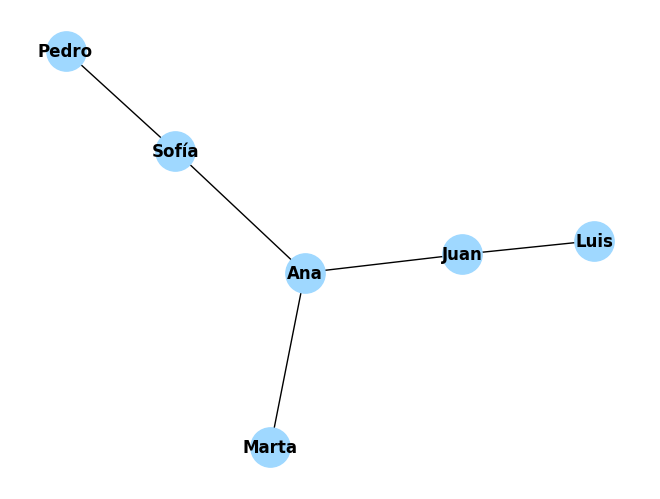

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# Un grafo NO dirigido: las aristas son amistades mutuas
G = nx.Graph()
G.add_nodes_from(["Ana", "Juan", "Marta", "Sofía", "Luis", "Pedro"])
G.add_edges_from([("Ana", "Juan"), ("Ana", "Sofía"), ("Juan", "Luis"),
                  ("Sofía", "Pedro"), ("Ana", "Marta")])

print("Nodos:", list(G.nodes()))
print("Aristas:", list(G.edges()))

# Centralidad de grado: grado de cada nodo / (nº de nodos - 1)
centralidad = nx.degree_centrality(G)
print("\nCentralidad de grado:")
for persona, c in sorted(centralidad.items(), key=lambda x: -x[1]):
    print(f"  {persona}: grado {G.degree(persona)}, centralidad {c:.2f}")

# Dibujo de la red
pos = nx.spring_layout(G, seed=42)  # seed fija el dibujo (reproducible)
nx.draw(G, pos, with_labels=True, node_size=800,
        node_color="#9fd8ff", font_weight="bold")
plt.show()


## 6) Combinatoria — contar sin enumerar

**Idea:** responder *"¿de cuántas formas puede pasar?"* sin tener que escribir todas las posibilidades a mano. Base del cálculo de probabilidades, complejidad y muestreo en Big Data.


# 🎲 El contexto: formar equipos y crear códigos

Imagina que tu empresa tiene 3 analistas — Ana, Juan y Marta — y se pregunta cosas como:

*   ¿De cuántas formas puedo **ordenarlos** en una fila para la foto?
*   ¿Cuántas **parejas ordenadas** (presidente + secretario) puedo formar?
*   ¿Cuántas **parejas sin orden** (equipo de dos) puedo formar?
*   ¿Cuántos **menús** (plato + bebida) puede ofrecer el comedor?

Contar *a mano* sirve con 3 personas. Con 3 millones, no. La combinatoria da **fórmulas** para contar sin enumerar.

---

## 1️⃣ El factorial: `n!` — *«¿de cuántas formas puedo ORDENAR n cosas?»*

$$n! = n \cdot (n-1) \cdot (n-2) \cdots 2 \cdot 1$$

La idea: para la primera posición eliges entre `n` opciones, para la segunda quedan `n-1`, y así hasta 1. Se **multiplican** porque cada elección se combina con todas las demás (regla del producto):

$$3! = 3 \cdot 2 \cdot 1 = 6 \text{ ordenaciones}$$

Con 10 elementos ya son 3.628.800. Con 20, más de 2,4 trillones (2,4·10¹⁸). **El factorial explota muy rápido** — esa es la primera lección de combinatoria para Big Data.

---

## 2️⃣ Permutaciones — *todas las ordenaciones*

`permutations(grupo)` genera las `n!` ordenaciones posibles. Con `permutations(grupo, k)` genera solo las que usan `k` elementos en orden (a veces llamadas **variaciones**): *"presidente y secretario"* — si Ana es presidenta y Juan secretario, NO es lo mismo que al revés. Hay `n·(n-1)` opciones.

---

## 3️⃣ Combinaciones — *elegir sin importar el orden*

`combinations(grupo, k)` genera los subgrupos de tamaño `k` **donde el orden no cuenta**: el equipo {Ana, Juan} es el mismo equipo que {Juan, Ana}. La fórmula divide las ordenadas entre las repeticiones:

$$\binom{n}{k} = \frac{n!}{k!\,(n-k)!}$$

Para 3 personas y equipos de 2: 3! / (2!·1!) = **3 equipos**.

**Para qué sirve:** "¿cuántas muestras aleatorias de 1000 clientes puedo sacar?" (muestreo), "¿cuántas parejas de variables puedo cruzar?" (correlaciones), "¿cuántas combinaciones de flags puede tener un usuario?" (tests A/B).

---

## 4️⃣ Regla del producto — *menús y producto cartesiano*

`product(platos, bebidas)` es el producto cartesiano de la sección de conjuntos, visto desde el conteo: si hay `p` platos y `b` bebidas, hay `p · b` menús. Es la regla más simple y la que más se olvida: **cuando las elecciones son independientes, se multiplican**.

⚠️ **El peligro del producto en Big Data:** multiplicar también multiplica filas. Un JOIN cruzado (producto cartesiano) entre una tabla de 1 millón de filas y otra de 1 millón genera 10¹² filas. Por eso las bases de datos reales evitan los JOIN sin condición.

---

## 🎯 Resumen

| Pregunta de negocio | Concepto | Herramienta Python | Con 3 elementos |
|---|---|---|---|
| ¿Cuántas filas/ordenaciones? | Factorial | `math.factorial(n)` | 6 |
| ¿Parejas CON orden (cargo 1, cargo 2)? | Permutaciones/Variaciones | `permutations(g, k)` | 6 |
| ¿Equipos SIN orden? | Combinaciones | `combinations(g, k)` | 3 |
| ¿Menús plato+bebida? | Regla del producto | `product(A, B)` | p·b |

> 💡 **La idea clave:** antes de enumerar, pregúntate dos cosas: **¿importa el orden?** y **¿puedo repetir elementos?** Según las respuestas caes en permutación, combinación o producto. En Big Data, contar bien es la diferencia entre un cálculo instantáneo y uno inviable.


In [6]:
from itertools import permutations, combinations, product
import math

grupo = ["Ana", "Juan", "Marta"]

# 1) Factorial: formas de ordenar n elementos
# 3! = 3·2·1 = 6 (para la 1ª posición 3 opciones, para la 2ª quedan 2, la última 1)
print("3! =", math.factorial(3))
print("10! =", math.factorial(10))          # ya son 3.628.800
print("20! =", math.factorial(20))          # ¡más de 2 trillones!

# 2) Permutaciones: todas las ordenaciones
print("\nOrdenaciones de la foto:", list(permutations(grupo)))

# Variaciones: elegir k elementos CON orden (presidente y secretario)
print("Presidente+secretario:", list(permutations(grupo, 2)))

# 3) Combinaciones: elegir k elementos SIN orden (equipo de dos)
print("Equipos de dos:", list(combinations(grupo, 2)))

# 4) Regla del producto: menús plato + bebida
platos = ["macarrones", "lentejas"]
bebidas = ["agua", "zumo"]
print("\nMenús posibles:", list(product(platos, bebidas)))
print("Total menús:", len(platos) * len(bebidas))


3! = 6
10! = 3628800
20! = 2432902008176640000

Ordenaciones de la foto: [('Ana', 'Juan', 'Marta'), ('Ana', 'Marta', 'Juan'), ('Juan', 'Ana', 'Marta'), ('Juan', 'Marta', 'Ana'), ('Marta', 'Ana', 'Juan'), ('Marta', 'Juan', 'Ana')]
Presidente+secretario: [('Ana', 'Juan'), ('Ana', 'Marta'), ('Juan', 'Ana'), ('Juan', 'Marta'), ('Marta', 'Ana'), ('Marta', 'Juan')]
Equipos de dos: [('Ana', 'Juan'), ('Ana', 'Marta'), ('Juan', 'Marta')]

Menús posibles: [('macarrones', 'agua'), ('macarrones', 'zumo'), ('lentejas', 'agua'), ('lentejas', 'zumo')]
Total menús: 4


## 7) Teoría de grupos (visión aplicada) — aritmética modular

**Idea:** entender los sistemas que "dan la vuelta" (como un reloj) y ver una aplicación directa: el **cifrado César**, antepasado de la criptografía moderna.


# 🔐 El contexto: un reloj de 26 horas

¿Qué hora es 5 horas después de las 22:00? Las 3:00. No las 27:00: **el reloj da la vuelta**. Esa operación de "dar la vuelta" es la **aritmética modular**, y se escribe con `mod`:

$$27 \bmod 12 = 3$$

(leído: "27 módulo 12 es 3"). El `mod` devuelve **el resto de la división**: 27 dividido entre 12 da 2 y **sobran 3**.

A las letras les pasa igual si las numeramos de la A=0 a la Z=25: tenemos un "reloj de 26 horas". El conjunto resultante se llama **Z₂₆** = {0, 1, 2, …, 25} con la operación suma que da la vuelta.

---

## 1️⃣ Las tres propiedades de un grupo, explicadas

Un **grupo** es un conjunto + una operación que cumplen tres condiciones. Comprobémoslas en (Z₂₆, +) con ejemplos de negocio:

*   **Clausura** (*no se escapa nadie*): sumar dos elementos nunca sale del conjunto. `20 + 10 = 30`, pero `30 mod 26 = 4` → volvemos a estar dentro de Z₂₆. Como un reloj: la suma de dos horas siempre es otra hora.
*   **Elemento neutro** (*el que no cambia nada*): el 0. Sumar 0 a cualquier número lo deja igual. En el reloj: esperar 0 horas.
*   **Elemento inverso** (*el que deshace la operación*): para cada `x` existe un `y` tal que `x + y = 0 (mod 26)`. El inverso de 3 es 23, porque `3 + 23 = 26 ≡ 0`. En el reloj: si avanzas 3 horas, esperar 9 más te devuelve al punto de partida.

**Por qué importa:** cuando un sistema cumple estas tres propiedades, puedes "deshacer" operaciones con garantías. Eso es la base de la criptografía (cifrar y descifrar), de los checksums (detectar errores), de los hashes distribuidos…

---

## 2️⃣ Aplicación: el cifrado César

Julio César cifraba sus mensajes **desplazando cada letra 3 posiciones** en el alfabeto. Con nuestro reloj de 26:

*   **Cifrar**: `(posición de la letra + 3) mod 26`
*   **Descifrar**: `(posición de la letra − 3) mod 26`

El `mod` es lo que permite que la Z (posición 25) al desplazarse 3 vuelva a la C: `28 mod 26 = 2`. Y descifrar es posible porque el desplazamiento tiene **inverso** (−3): la propiedad de grupo en acción.

Hoy en día el César se rompe en segundos (¡solo hay 26 desplazamientos que probar!), pero **AES y la criptografía moderna son la misma idea llevada al extremo**: transformar datos con operaciones que se pueden deshacer solo con la clave.

---

## 🎯 Resumen

| Concepto | En el reloj de 12 | En Z₂₆ (letras) | En el código |
|---|---|---|---|
| Aritmética modular | 22:00 + 5h = 3:00 | 25 + 3 → 2 (Z→C) | `(a + b) % 26` |
| Clausura | la suma es siempre una hora | la suma es siempre una letra | `30 % 26 = 4` |
| Neutro | esperar 0 horas | sumar 0 | `x + 0 = x` |
| Inverso | avanzar 3h + esperar 9h | +3 y −3 (César) | `(26 - x) % 26` |

> 💡 **La idea clave:** "dar la vuelta" (módulo) no es un truco de programación: es un sistema matemático con estructura (grupo). Y esa estructura es lo que hace posible cifrar y descifrar con seguridad matemática. Cuando en Big Data repartes datos entre servidores con `id % nº_servidores` (hashing), estás usando exactamente la misma aritmética.


In [7]:
# Aritmética modular: el "reloj" de 12 horas, aquí de 26 letras
def suma_mod26(a, b):
    return (a + b) % 26  # % es el resto de la división → "dar la vuelta"

letras = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
elementos = list(range(26))

# 1) Clausura: la suma nunca sale del conjunto (30 vuelve a ser 4)
print("suma_mod26(20, 10) =", suma_mod26(20, 10))

# 2) Neutro: sumar 0 no cambia nada
print("¿0 es neutro?", all(suma_mod26(x, 0) == x for x in elementos))

# 3) Inverso: cada x tiene un y con x + y = 0 (mod 26)
inverso = lambda x: (26 - x) % 26
print("Inverso de 3:", inverso(3), "→", suma_mod26(3, inverso(3)))

# Aplicación: cifrado César (desplazar cada letra k posiciones)
def cifrar(mensaje, k=3):
    return "".join(letras[(letras.index(c) + k) % 26] if c in letras else c
                   for c in mensaje.upper())

def descifrar(mensaje, k=3):
    return "".join(letras[(letras.index(c) - k) % 26] if c in letras else c
                   for c in mensaje.upper())

secreto = cifrar("BIGDATA")
print("\n'BIGDATA' cifrado con k=3:", secreto)
print("Descifrado de nuevo:", descifrar(secreto))


suma_mod26(20, 10) = 4
¿0 es neutro? True
Inverso de 3: 23 → 0

'BIGDATA' cifrado con k=3: ELJGDWD
Descifrado de nuevo: BIGDATA


## 8) Estructuras de datos — vectores, matrices, tablas y árboles

**Idea:** las matemáticas discretas que hemos visto (conjuntos, relaciones, grafos) se *materializan* en Python en cuatro estructuras que usarás a diario en Big Data: **vectores**, **matrices**, **tablas** y **árboles**.


# 🧱 El contexto: del concepto matemático a la herramienta

Todo lo que hemos visto hasta ahora tiene una "encarnación" práctica:

| Concepto matemático | Estructura de datos | Herramienta típica |
|---|---|---|
| Vector (lista de números) | Array de 1 dimensión | `numpy` |
| Matriz (tabla de números) | Array de 2 dimensiones | `numpy` |
| Relación / tabla de pares | DataFrame | `pandas` |
| Grafo sin ciclos (jerarquía) | Árbol (diccionario anidado) | pura Python / `networkx` |

---

## 1️⃣ Vectores — *una fila de números*

```
ventas  = np.array([120, 90, 200, 150])   # unidades vendidas por producto
precios = np.array([10.0, 25.0, 5.0, 8.0])
```

Un vector es la forma natural de guardar *"una medida para cada elemento de una lista"*. La magia de numpy: las operaciones se aplican **a todo el vector a la vez** (`ventas * precios` calcula los 4 ingresos sin escribir ningún bucle). Eso, a escala de millones, es muchísimo más rápido que un `for`.

El **producto escalar** (`ventas @ precios`) multiplica elemento a elemento y suma: el ingreso total en un solo paso. Es LA operación del machine learning (regresión, redes neuronales…).

---

## 2️⃣ Matrices — *números en cuadrícula*

```
matriz = np.array([[1, 2], [3, 4]])
```

Una matriz es una tabla de números: **filas × columnas**. Representa relaciones entre dos conjuntos (fila = origen, columna = destino), imágenes (píxeles), distancias entre ciudades, coeficientes de sistemas de ecuaciones… `axis=0`/`axis=1` indica si agregas **por columnas** o **por filas**.

---

## 3️⃣ Tablas (DataFrame) — *la relación, hecha herramienta*

```
df = pd.DataFrame({"producto": [...], "cliente": [...], "unidades": [...]})
```

Un DataFrame es literalmente **una relación matemática de la sección 2**, pero con superpoderes: agrupar (`groupby`), filtrar, cruzar (`merge` = JOIN). Es LA estructura del análisis de datos: cada fila es un registro, cada columna un campo. El `groupby("producto")["unidades"].sum()` es la pregunta de negocio *"¿cuántas unidades de cada producto he vendido?"* — agrupar por clave y agregar.

---

## 4️⃣ Árboles — *jerarquías*

```
familia = {"Abuela": ["Madre", "Tío"], "Madre": ["Ana", "Juan"], ...}
```

Un árbol es un **grafo sin ciclos** donde cada nodo apunta a sus "hijos": organigramas, carpetas de archivos, categorías de productos, la estructura de un XML o HTML. Fíjate: se guarda en un **diccionario de listas** — ¡una lista de adyacencia como la de la sección 2! Recorrerlo (función `mostrar`) usa **recursión**: la función se llama a sí misma para bajar un nivel.

---

## 🎯 Resumen

| Estructura | Dimensión | Pregunta típica | Herramienta |
|---|---|---|---|
| Vector | 1D | ¿ingreso por producto? | `np.array`, `@` |
| Matriz | 2D | ¿distancias/relaciones entre pares? | `np.array` + `axis` |
| Tabla | registros × campos | ¿agregaciones por grupo? | `pd.DataFrame`, `groupby` |
| Árbol | jerarquía | ¿quién depende de quién? | dict de listas + recursión |

> 💡 **La idea clave:** en Big Data no trabajas con números sueltos sino con **vectores, tablas y grafos de millones de elementos**. Reconocer en cada herramienta la estructura matemática que hay debajo (numpy = álgebra lineal, pandas = relaciones, networkx = teoría de grafos) es lo que te permite elegir la herramienta correcta y entender su coste.


In [8]:
import numpy as np
import pandas as pd

# 1) Vectores: una medida por elemento (aquí, por producto)
ventas = np.array([120, 90, 200, 150])
precios = np.array([10.0, 25.0, 5.0, 8.0])
print("Ingreso por producto (sin bucles):", ventas * precios)
print("Ingreso total (producto escalar):", ventas @ precios)

# 2) Matrices: números en cuadrícula (fila x columna)
matriz = np.array([[1, 2], [3, 4]])
print("\nMatriz:\n", matriz)
print("Suma por columnas (axis=0):", matriz.sum(axis=0))
print("Suma por filas (axis=1):", matriz.sum(axis=1))

# 3) Tabla de datos: una relación matemática con superpoderes
df = pd.DataFrame({
    "producto": ["X", "Y", "X", "Y"],
    "cliente":  ["Ana", "Ana", "Juan", "Sofía"],
    "unidades": [3, 1, 2, 5],
})
print("\nTabla de datos:\n", df)
print("\nUnidades vendidas por producto (agrupar + sumar):\n",
      df.groupby("producto")["unidades"].sum())

# 4) Árbol: jerarquía guardada como diccionario de listas (lista de adyacencia)
familia = {"Abuela": ["Madre", "Tío"], "Madre": ["Ana", "Juan"],
           "Tío": [], "Ana": [], "Juan": []}

def mostrar(arbol, nodo, nivel=0):
    print("   " * nivel + "└─ " * (nivel > 0) + nodo)
    for hijo in arbol[nodo]:
        mostrar(arbol, hijo, nivel + 1)  # recursión: bajar un nivel

print("\nÁrbol genealógico:")
mostrar(familia, "Abuela")


Ingreso por producto (sin bucles): [1200. 2250. 1000. 1200.]
Ingreso total (producto escalar): 5650.0

Matriz:
 [[1 2]
 [3 4]]
Suma por columnas (axis=0): [4 6]
Suma por filas (axis=1): [3 7]

Tabla de datos:
   producto cliente  unidades
0        X     Ana         3
1        Y     Ana         1
2        X    Juan         2
3        Y   Sofía         5

Unidades vendidas por producto (agrupar + sumar):
 producto
X    5
Y    6
Name: unidades, dtype: int64

Árbol genealógico:
Abuela
   └─ Madre
      └─ Ana
      └─ Juan
   └─ Tío


# 🎓 Cierre del cuaderno

Has recorrido, con el mismo grupo de personas como hilo conductor:

1. **Conjuntos** → operaciones y preguntas de negocio (audiencias, cross-selling)
2. **Relaciones** → pares ordenados, propiedades (reflexiva, simétrica), lista de adyacencia
3. **Funciones** → dominio, transformaciones y composición (el *pipeline* de datos)
4. **Lógica** → predicados y reglas de negocio (AND/OR/NOT ↔ intersección/unión/complemento)
5. **Grafos** → redes, centralidad, el puente entre relaciones y estructura global
6. **Combinatoria** → contar sin enumerar (permutaciones, combinaciones, producto)
7. **Teoría de grupos** → aritmética modular y criptografía (César)
8. **Estructuras de datos** → vectores, matrices, tablas y árboles como materialización de todo lo anterior

> 💡 **La idea final:** Big Data no es "mucho Python": es matemática discreta (conjuntos, relaciones, lógica, grafos) ejecutada a escala industrial. Cada `merge` de pandas es una operación de conjuntos; cada filtro es lógica de predicados; cada recomendador es un grafo; cada modelo es álgebra lineal. Dominar estos fundamentos es lo que distingue a quien usa las herramientas de quien las entiende.
